<a href="https://colab.research.google.com/github/Gurirath/VIT---EDA---Projects---Classwork--25BAI0153/blob/main/22_9_2026%20Classwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

In [3]:
uploaded = files.upload()

Saving airline-passengers.csv to airline-passengers.csv


In [4]:
for fn in uploaded.keys():
  filename = fn
df = pd.read_csv(io.BytesIO(uploaded[filename]))

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month             144 non-null    object
 1   total_passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [6]:
df.head()

,month,total_passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [7]:
print(df.shape)

(144, 2)


In [8]:
df.isnull().sum()

,0
month,0
total_passengers,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['month'] = pd.to_datetime(df['month'])
df.set_index('month', inplace=True)

KeyError: 'month'

In [ ]:
df.head()

In [ ]:
df.sample(5)

In [22]:
df_1955 = df.loc['1955-01-01':'1955-12-31']
display(df_1955.head())

,total_passengers,Cumulative_total_passengers,Rolling_Mean_12M,Month
month,,,,
1955-01-01,242,13411,242.083333,1
1955-02-01,233,13644,245.833333,2
1955-03-01,267,13911,248.500000,3
1955-04-01,269,14180,252.000000,4
1955-05-01,270,14450,255.000000,5


In [23]:
df_march_1956 = df.loc['1956-03-01':'1956-03-31']
display(df_march_1956)

,total_passengers,Cumulative_total_passengers,Rolling_Mean_12M,Month
month,,,,
1956-03-01,317,17455,295.333333,3


In [24]:
df_mid_1957 = df.loc['1957-01-01':'1957-06-30']
display(df_mid_1957.head())

,total_passengers,Cumulative_total_passengers,Rolling_Mean_12M,Month
month,,,,
1957-01-01,315,20831,330.833333,1
1957-02-01,301,21132,332.833333,2
1957-03-01,356,21488,336.083333,3
1957-04-01,348,21836,339.000000,4
1957-05-01,355,22191,342.083333,5


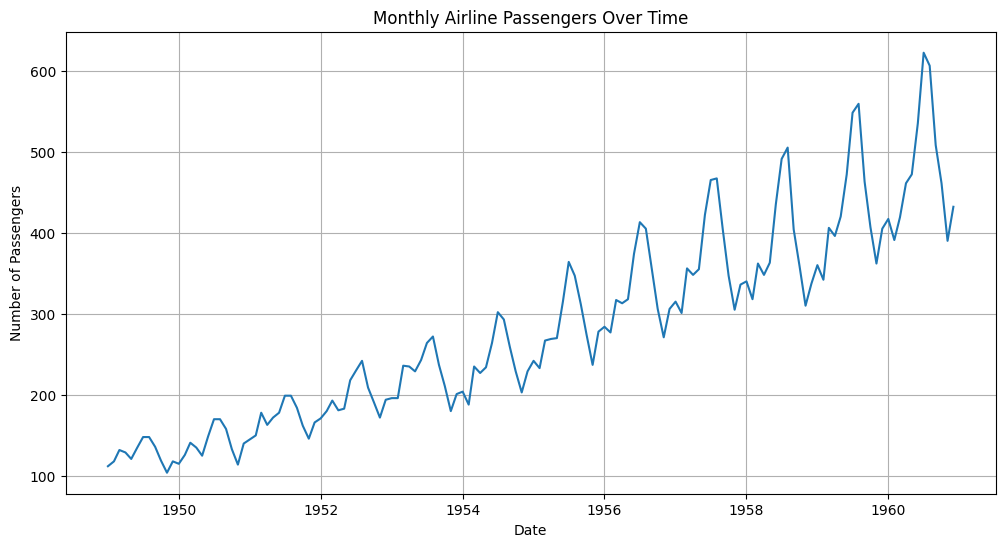

In [16]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='total_passengers')
plt.title('Monthly Airline Passengers Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

In [17]:
df['Cumulative_total_passengers'] = df['total_passengers'].cumsum()

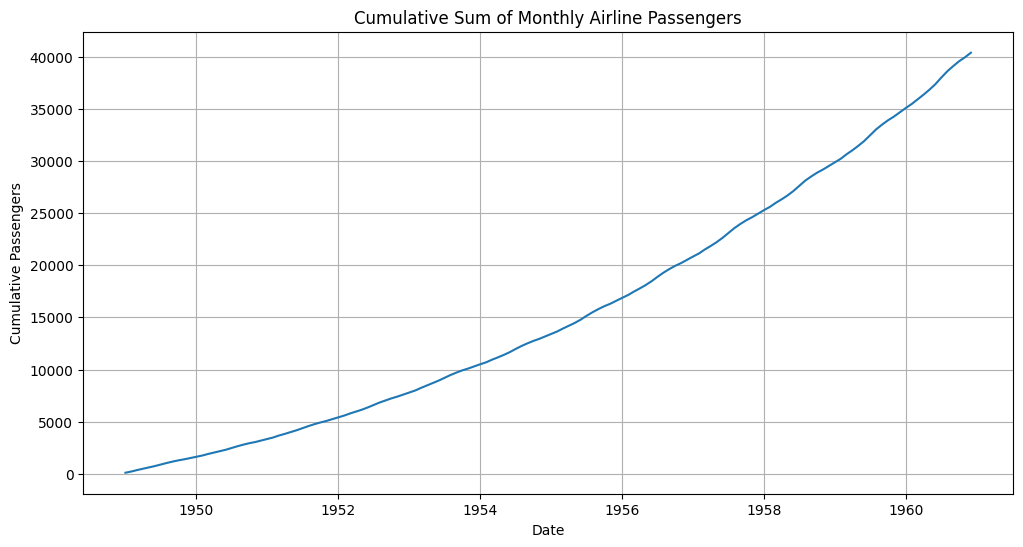

In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='Cumulative_total_passengers')
plt.title('Cumulative Sum of Monthly Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Cumulative Passengers')
plt.grid(True)
plt.show()

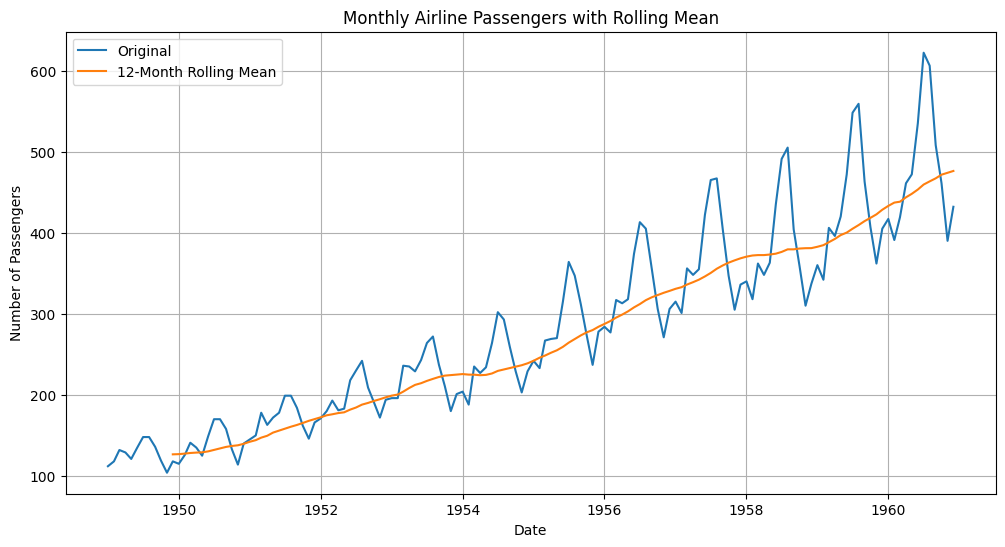

In [19]:
df['Rolling_Mean_12M'] = df['total_passengers'].rolling(window=12).mean()
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='total_passengers', label='Original')
sns.lineplot(data=df, x=df.index, y='Rolling_Mean_12M', label='12-Month Rolling Mean')
plt.title('Monthly Airline Passengers with Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

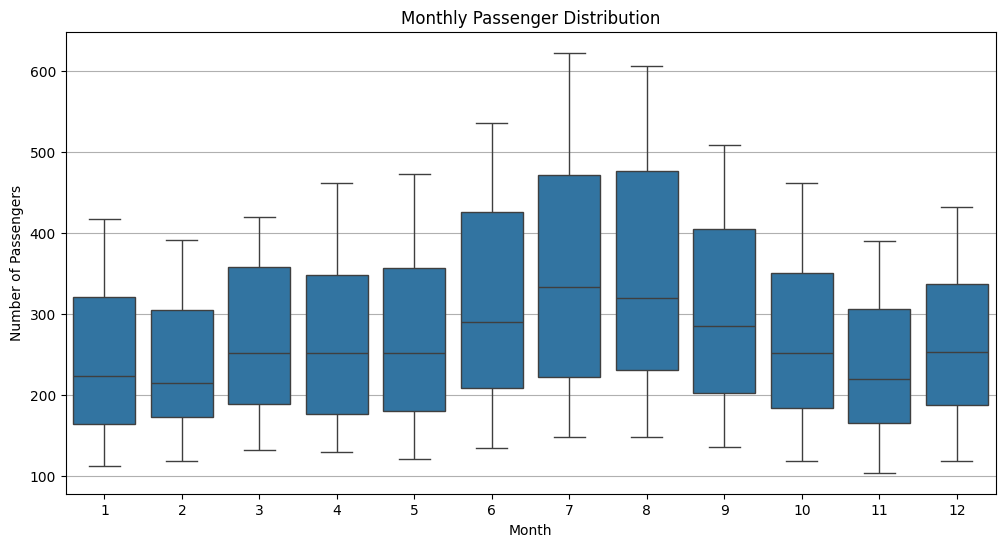

In [20]:
df['Month'] = df.index.month
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='total_passengers', data=df)
plt.title('Monthly Passenger Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.grid(axis='y')
plt.show()

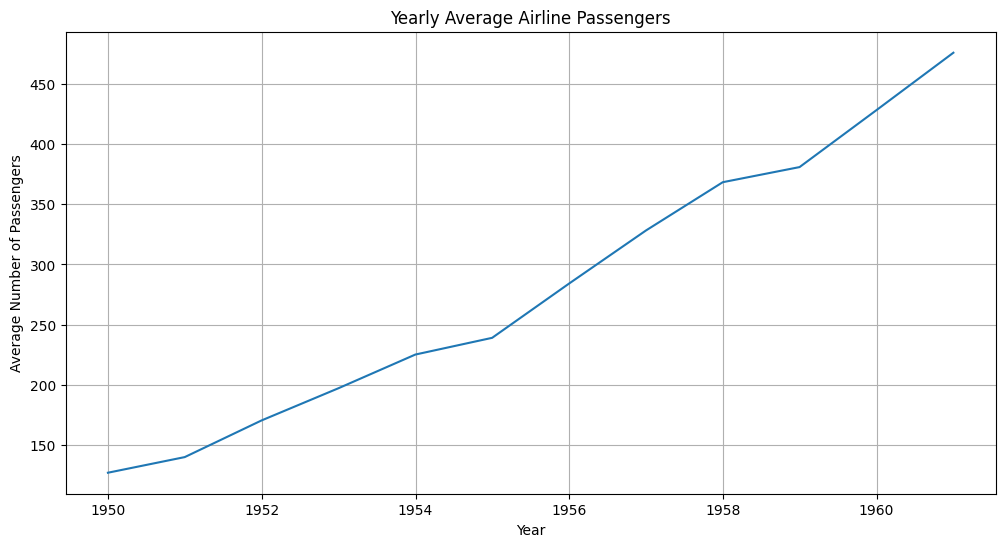

In [25]:
df_yearly_avg = df['total_passengers'].resample('YE').mean()
plt.figure(figsize=(12, 6))
sns.lineplot(x=df_yearly_avg.index, y=df_yearly_avg.values)
plt.title('Yearly Average Airline Passengers')
plt.xlabel('Year')
plt.ylabel('Average Number of Passengers')
plt.grid(True)
plt.show()

In [29]:
df['total_passengers'].index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='month', length=144, freq=None)